In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
UAPP Ablation Study — Full Experimental Notebook
=================================================

Blocks:
  A  Input representation   (A0–A4)
  B  Mean-variance coupling (MSE → NLL single → two-head → two-stage → regularized)
  C  Likelihood family      (Gaussian, Student-t ν=3/5, Laplace)
  D  Uncertainty quality    (ICE, coverage, corr, σ-distribution, RSA, case studies)

Prerequisites:
  1. cache/t2837_embeddings.pt         (A0, 320-d)
  2. cache/t2837_embeddings_A1.pt      (A1, 320-d site-only)
  3. cache/t2837_embeddings_A2.pt      (A2, 640-d site+window)
  4. cache/t2837_embeddings_v2.pt      (A3, 680-d mutation-aware)
  5. cache/t2837_embeddings_A4.pt      (A4, 40-d AA-only)
  6. cache/t2837_metadata.csv

Run:
  jupytext --to notebook ablation_notebook.py && jupyter notebook ablation_notebook.ipynb
  # or just:  python ablation_notebook.py
"""


'\nUAPP Ablation Study — Full Experimental Notebook\n=================================================\n\nBlocks:\n  A  Input representation   (A0–A4)\n  B  Mean-variance coupling (MSE → NLL single → two-head → two-stage → regularized)\n  C  Likelihood family      (Gaussian, Student-t ν=3/5, Laplace)\n  D  Uncertainty quality    (ICE, coverage, corr, σ-distribution, RSA, case studies)\n\nPrerequisites:\n  1. cache/t2837_embeddings.pt         (A0, 320-d)\n  2. cache/t2837_embeddings_A1.pt      (A1, 320-d site-only)\n  3. cache/t2837_embeddings_A2.pt      (A2, 640-d site+window)\n  4. cache/t2837_embeddings_v2.pt      (A3, 680-d mutation-aware)\n  5. cache/t2837_embeddings_A4.pt      (A4, 40-d AA-only)\n  6. cache/t2837_metadata.csv\n\nRun:\n  jupytext --to notebook ablation_notebook.py && jupyter notebook ablation_notebook.ipynb\n  # or just:  python ablation_notebook.py\n'

# UAPP — Uncertainty-Aware Protein Stability Prediction
## Complete Ablation Study


In [2]:
import sys, os, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats as sp_stats

# ── UAPP library imports ───────────────────────────────────────────────
sys.path.insert(0, ".")
from uapp.data import load_cached_embeddings, make_loader
from uapp.heads import build_head, is_probabilistic, TwoHeadNLL
from uapp.train import train_head, train_head_two_stage, TrainConfig
from uapp.evaluate import (
    evaluate_head,
    compute_coverage_curve,
    gather_probabilistic_predictions,
    plot_reliability_diagram,
    save_results_json,
    EvalResult,
)
from uapp.losses import (
    mse_loss,
    gaussian_nll_loss,
    student_t_nll_loss,
    regularized_nll_loss,
)

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")
log = logging.getLogger("ablation")

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 10,
    "legend.fontsize": 8, "figure.facecolor": "white",
})

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CACHE_DIR = Path("cache")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 256

print(f"Device: {DEVICE}")


Device: mps


In [3]:

CACHE_MAP = {
    "A0": "t2837_embeddings.pt",
    "A1": "t2837_embeddings_A1.pt",
    "A2": "t2837_embeddings_A2.pt",
    "A3": "t2837_embeddings_v2.pt",
    "A4": "t2837_embeddings_A4.pt",
}

REPR_LABELS = {
    "A0": "Global mean (320d)",
    "A1": "Site-only (320d)",
    "A2": "Site+window (640d)",
    "A3": "Site+window+AA (680d)",
    "A4": "AA one-hot (40d)",
}


def load_split_loaders(tag: str):
    """Load cache and return (loaders_dict, input_dim)."""
    path = CACHE_DIR / CACHE_MAP[tag]
    splits, meta = load_cached_embeddings(path)
    dim = meta.get("d", next(iter(splits.values()))[0].shape[-1])
    loaders = {
        name: make_loader(X, y, batch_size=BATCH_SIZE, shuffle=(name == "train"))
        for name, (X, y) in splits.items()
    }
    return loaders, dim


meta_df = pd.read_csv(CACHE_DIR / "t2837_metadata.csv")
print(f"Metadata: {len(meta_df)} rows, splits: {meta_df['split'].value_counts().to_dict()}")


Metadata: 2584 rows, splits: {'train': 1395, 'val': 1019, 'test': 170}


In [4]:


def run_experiment(
    cache_tag: str,
    head_name: str,
    train_cfg: TrainConfig,
    experiment_label: str,
    two_stage: bool = False,
    stage1_cfg: TrainConfig | None = None,
) -> tuple[EvalResult, object, dict]:
    """
    Load data -> build head -> train -> evaluate on test.

    Returns (EvalResult, trained_head, extra_info_dict).
    """
    loaders, dim = load_split_loaders(cache_tag)
    head = build_head(head_name, d_in=dim)

    if two_stage:
        assert stage1_cfg is not None, "stage1_cfg required for two-stage"
        head, hist1, hist2 = train_head_two_stage(
            head, loaders["train"], loaders["val"],
            config_stage1=stage1_cfg,
            config_stage2=train_cfg,
            device=DEVICE,
        )
        histories = {"stage1": hist1, "stage2": hist2}
    else:
        head, history = train_head(
            head, loaders["train"], loaders["val"],
            config=train_cfg, device=DEVICE,
        )
        histories = {"train": history}

    result = evaluate_head(head, loaders["test"], DEVICE, head_name=experiment_label)
    log.info(result.pretty())

    # Gather predictions for downstream plotting
    extra = {"cache_tag": cache_tag, "dim": dim, "histories": histories}
    if is_probabilistic(head):
        mu, sigma, y = gather_probabilistic_predictions(head, loaders["test"], DEVICE)
        extra["mu"] = mu
        extra["sigma"] = sigma
        extra["y"] = y
    else:
        # For MSE head, gather mu and y only
        head.eval()
        head.to(DEVICE)
        mus, ys = [], []
        with torch.no_grad():
            for X_b, y_b in loaders["test"]:
                mus.append(head(X_b.to(DEVICE)).cpu().numpy())
                ys.append(y_b.numpy())
        extra["mu"] = np.concatenate(mus)
        extra["sigma"] = None
        extra["y"] = np.concatenate(ys)

    return result, head, extra


---
## Block A — Input Representation

| Tag | Description | Dim |
|-----|-------------|-----|
| A0  | Global mean-pool | 320 |
| A1  | Site-only (mutation residue) | 320 |
| A2  | Site + window (±3) | 640 |
| A3  | Site + window + AA one-hot | 680 |
| A4  | AA one-hot only | 40 |


In [5]:

block_a_results: list[EvalResult] = []
block_a_extras: dict[str, dict] = {}

cfg_a = TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="gaussian")

for tag in ["A0", "A1", "A2", "A3", "A4"]:
    label = f"A_{tag}"
    print(f"\n{'='*55}\n  Block A: {tag}  —  {REPR_LABELS[tag]}\n{'='*55}")
    result, head, extra = run_experiment(
        cache_tag=tag, head_name="two_head_nll",
        train_cfg=cfg_a, experiment_label=label,
    )
    block_a_results.append(result)
    block_a_extras[tag] = extra

df_a = pd.DataFrame([
    {
        "tag": r.head_name, "dim": block_a_extras[r.head_name.split("_")[1]]["dim"],
        "RMSE": r.rmse, "MAE": r.mae,
        "NLL": r.nll, "ICE": r.ice,
        "cov@90": r.coverage.get("0.90") if r.coverage else None,
    }
    for r in block_a_results
])
print("\n", df_a.to_string(index=False))



  Block A: A0  —  Global mean (320d)


uapp.train | [train] epoch   1 | train 3.4189 | val 1.1553 | best 1.1553 @ ep 1
uapp.train | [train] epoch  10 | train 1.1070 | val 0.9681 | best 0.9551 @ ep 2
uapp.train | [train] epoch  20 | train 1.0596 | val 1.0847 | best 0.9551 @ ep 2
uapp.train | [train] epoch  30 | train 1.0346 | val 1.7433 | best 0.9551 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 0.9551 @ ep 2)
ablation | [A_A0] n=398
  RMSE : 1.5689
  MAE  : 1.2689
  NLL  : 1.8883
  ICE  : 0.0261
  cov: 0.50→0.482, 0.80→0.786, 0.90→0.867, 0.95→0.945
uapp.train | [train] epoch   1 | train 3.0113 | val 2.8827 | best 2.8827 @ ep 1



  Block A: A1  —  Site-only (320d)


uapp.train | [train] epoch  10 | train 0.8757 | val 1.2864 | best 1.1489 @ ep 5
uapp.train | [train] epoch  20 | train 0.7101 | val 1.5103 | best 1.1489 @ ep 5
uapp.train | [train] epoch  30 | train 0.5569 | val 1.8297 | best 1.1489 @ ep 5
uapp.train | [train] early stop at epoch 35 (best 1.1489 @ ep 5)
ablation | [A_A1] n=170
  RMSE : 1.5071
  MAE  : 1.1392
  NLL  : 1.8780
  ICE  : 0.0622
  cov: 0.50→0.612, 0.80→0.894, 0.90→0.935, 0.95→0.959
uapp.train | [train] epoch   1 | train 2.7573 | val 1.7271 | best 1.7271 @ ep 1



  Block A: A2  —  Site+window (640d)


...


  Block A: A3  —  Site+window+AA (680d)


uapp.train | [train] epoch  10 | train 0.7761 | val 1.4936 | best 1.1388 @ ep 3
uapp.train | [train] epoch  20 | train 0.5268 | val 1.6927 | best 1.1388 @ ep 3
uapp.train | [train] epoch  30 | train 0.3446 | val 2.0189 | best 1.1388 @ ep 3
uapp.train | [train] early stop at epoch 33 (best 1.1388 @ ep 3)
ablation | [A_A3] n=170
  RMSE : 1.5558
  MAE  : 1.2079
  NLL  : 1.9446
  ICE  : 0.1039
  cov: 0.50→0.700, 0.80→0.935, 0.90→0.965, 0.95→0.976
uapp.train | [train] epoch   1 | train 3.7549 | val 6.0506 | best 6.0506 @ ep 1



  Block A: A4  —  AA one-hot (40d)


uapp.train | [train] epoch  10 | train 1.6989 | val 2.5726 | best 2.5726 @ ep 10
uapp.train | [train] epoch  20 | train 1.1728 | val 1.5493 | best 1.5493 @ ep 20
uapp.train | [train] epoch  30 | train 1.0859 | val 1.3274 | best 1.3274 @ ep 30
uapp.train | [train] epoch  40 | train 1.0831 | val 1.2899 | best 1.2899 @ ep 40
uapp.train | [train] epoch  50 | train 1.0792 | val 1.2851 | best 1.2843 @ ep 48
uapp.train | [train] epoch  60 | train 1.0806 | val 1.2855 | best 1.2843 @ ep 48
uapp.train | [train] epoch  70 | train 1.0794 | val 1.2843 | best 1.2833 @ ep 67
uapp.train | [train] epoch  80 | train 1.0842 | val 1.2850 | best 1.2833 @ ep 67
uapp.train | [train] epoch  90 | train 1.0836 | val 1.2835 | best 1.2813 @ ep 86
uapp.train | [train] epoch 100 | train 1.0785 | val 1.2816 | best 1.2795 @ ep 98
uapp.train | [train] epoch 110 | train 1.0815 | val 1.2841 | best 1.2795 @ ep 98
uapp.train | [train] epoch 120 | train 1.0799 | val 1.2853 | best 1.2795 @ ep 98
uapp.train | [train] early s


  tag  dim     RMSE      MAE      NLL      ICE   cov@90
A_A0  320 1.568914 1.268869 1.888310 0.026083 0.866834
A_A1  320 1.507136 1.139203 1.878003 0.062218 0.935294
A_A2  640 1.612349 1.270679 1.956129 0.079692 0.958824
A_A3  680 1.555847 1.207881 1.944562 0.103871 0.964706
A_A4   40 1.611315 1.187042 1.908231 0.076471 0.935294


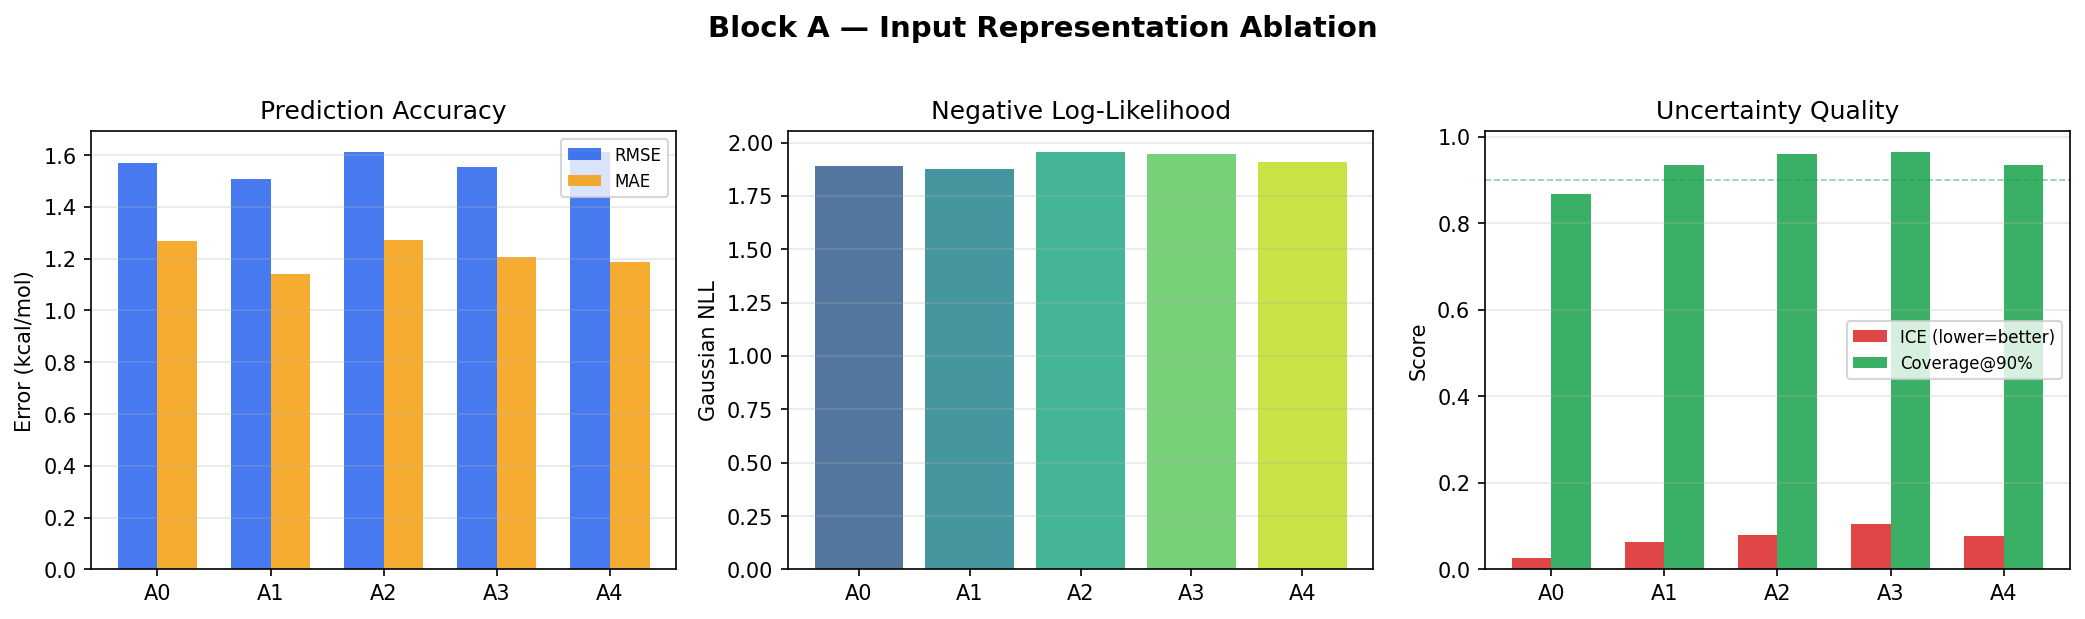

In [6]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = [REPR_LABELS[t] for t in ["A0", "A1", "A2", "A3", "A4"]]
short_labels = ["A0", "A1", "A2", "A3", "A4"]
x_pos = np.arange(len(short_labels))

# ── RMSE & MAE ──
ax = axes[0]
w = 0.35
ax.bar(x_pos - w / 2, df_a["RMSE"], w, label="RMSE", color="#2563eb", alpha=0.85)
ax.bar(x_pos + w / 2, df_a["MAE"], w, label="MAE", color="#f59e0b", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(short_labels)
ax.set_ylabel("Error (kcal/mol)")
ax.set_title("Prediction Accuracy")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ── NLL ──
ax = axes[1]
colors_a = plt.cm.viridis(np.linspace(0.3, 0.9, len(short_labels)))
ax.bar(x_pos, df_a["NLL"], color=colors_a, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(short_labels)
ax.set_ylabel("Gaussian NLL")
ax.set_title("Negative Log-Likelihood")
ax.grid(axis="y", alpha=0.3)

# ── ICE & Coverage ──
ax = axes[2]
ax.bar(x_pos - w / 2, df_a["ICE"], w, label="ICE (lower=better)", color="#dc2626", alpha=0.85)
ax.bar(x_pos + w / 2, df_a["cov@90"], w, label="Coverage@90%", color="#16a34a", alpha=0.85)
ax.axhline(0.9, color="#16a34a", ls="--", lw=0.8, alpha=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(short_labels)
ax.set_ylabel("Score")
ax.set_title("Uncertainty Quality")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Block A — Input Representation Ablation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "block_a_input_repr.png")
plt.show()


---
## Block B — Mean-Variance Coupling

All experiments use A3 (680-d) input.


In [7]:

block_b_results: list[EvalResult] = []
block_b_extras: dict[str, dict] = {}

b_experiments = [
    # (label, head_name, TrainConfig, two_stage, stage1_cfg)
    ("B_MSE", "mse",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30),
     False, None),

    ("B_SingleHead", "single_head_nll",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="gaussian"),
     False, None),

    ("B_TwoHead", "two_head_nll",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="gaussian"),
     False, None),

    ("B_TwoStage", "two_head_nll",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="gaussian"),
     True,
     TrainConfig(max_epochs=150, lr=1e-3, patience=20, loss_type="gaussian")),

    ("B_Regularized", "two_head_nll",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="regularized",
                 sigma_prior=1.5, lambda_reg=0.1),
     False, None),
]

for label, head_name, cfg, two_stage, stage1 in b_experiments:
    print(f"\n{'='*55}\n  Block B: {label}\n{'='*55}")
    result, head, extra = run_experiment(
        cache_tag="A3", head_name=head_name,
        train_cfg=cfg, experiment_label=label,
        two_stage=two_stage, stage1_cfg=stage1,
    )
    block_b_results.append(result)
    block_b_extras[label] = extra

df_b = pd.DataFrame([
    {
        "tag": r.head_name, "RMSE": r.rmse, "MAE": r.mae,
        "NLL": r.nll, "ICE": r.ice,
        "cov@90": r.coverage.get("0.90") if r.coverage else None,
    }
    for r in block_b_results
])
print("\n", df_b.to_string(index=False))


uapp.train | [train] epoch   1 | train 3.6884 | val 4.3583 | best 4.3583 @ ep 1



  Block B: B_MSE


uapp.train | [train] epoch  10 | train 1.9845 | val 3.9474 | best 3.7311 @ ep 6
uapp.train | [train] epoch  20 | train 1.4381 | val 4.1693 | best 3.7311 @ ep 6
uapp.train | [train] epoch  30 | train 1.1836 | val 4.0108 | best 3.7311 @ ep 6
uapp.train | [train] early stop at epoch 36 (best 3.7311 @ ep 6)
ablation | [B_MSE] n=170
  RMSE : 1.4265
  MAE  : 0.9939
uapp.train | [train] epoch   1 | train 2.0513 | val 1.6202 | best 1.6202 @ ep 1



  Block B: B_SingleHead


uapp.train | [train] epoch  10 | train 0.8236 | val 1.3860 | best 1.1535 @ ep 4
uapp.train | [train] epoch  20 | train 0.6034 | val 1.5579 | best 1.1535 @ ep 4
uapp.train | [train] epoch  30 | train 0.4421 | val 1.7020 | best 1.1535 @ ep 4
uapp.train | [train] early stop at epoch 34 (best 1.1535 @ ep 4)
ablation | [B_SingleHead] n=170
  RMSE : 1.5630
  MAE  : 1.1913
  NLL  : 1.9274
  ICE  : 0.0868
  cov: 0.50→0.676, 0.80→0.929, 0.90→0.953, 0.95→0.959
uapp.train | [train] epoch   1 | train 2.5286 | val 1.6955 | best 1.6955 @ ep 1


...


  Block B: B_TwoStage


uapp.train | [stage1-mu] epoch  10 | train 0.8554 | val 1.2629 | best 1.2410 @ ep 7
uapp.train | [stage1-mu] epoch  20 | train 0.7346 | val 1.3189 | best 1.2410 @ ep 7
uapp.train | [stage1-mu] early stop at epoch 27 (best 1.2410 @ ep 7)
uapp.train | === Stage 2: training sigma (NLL, mu frozen) ===
uapp.train | [stage2-sigma] epoch   1 | train 1.6241 | val 2.2007 | best 2.2007 @ ep 1
uapp.train | [stage2-sigma] epoch  10 | train 0.7875 | val 1.3784 | best 1.1647 @ ep 4
uapp.train | [stage2-sigma] epoch  20 | train 0.7172 | val 1.3274 | best 1.1647 @ ep 4
uapp.train | [stage2-sigma] epoch  30 | train 0.6681 | val 1.3037 | best 1.1647 @ ep 4
uapp.train | [stage2-sigma] early stop at epoch 34 (best 1.1647 @ ep 4)
ablation | [B_TwoStage] n=170
  RMSE : 1.4248
  MAE  : 0.9824
  NLL  : 1.8359
  ICE  : 0.1184
  cov: 0.50→0.671, 0.80→0.906, 0.90→0.929, 0.95→0.947
uapp.train | [train] epoch   1 | train 2.3494 | val 1.5694 | best 1.5694 @ ep 1



  Block B: B_Regularized


uapp.train | [train] epoch  10 | train 0.7918 | val 1.4186 | best 1.1561 @ ep 2
uapp.train | [train] epoch  20 | train 0.5857 | val 1.6833 | best 1.1561 @ ep 2
uapp.train | [train] epoch  30 | train 0.3999 | val 2.0326 | best 1.1561 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 1.1561 @ ep 2)
ablation | [B_Regularized] n=170
  RMSE : 1.5903
  MAE  : 1.2581
  NLL  : 1.9454
  ICE  : 0.0595
  cov: 0.50→0.559, 0.80→0.906, 0.90→0.941, 0.95→0.959



           tag     RMSE      MAE      NLL      ICE   cov@90
        B_MSE 1.426518 0.993854      NaN      NaN      NaN
 B_SingleHead 1.562997 1.191280 1.927447 0.086779 0.952941
    B_TwoHead 1.537511 1.186715 1.918151 0.096134 0.958824
   B_TwoStage 1.424755 0.982449 1.835932 0.118375 0.929412
B_Regularized 1.590309 1.258100 1.945429 0.059462 0.941176


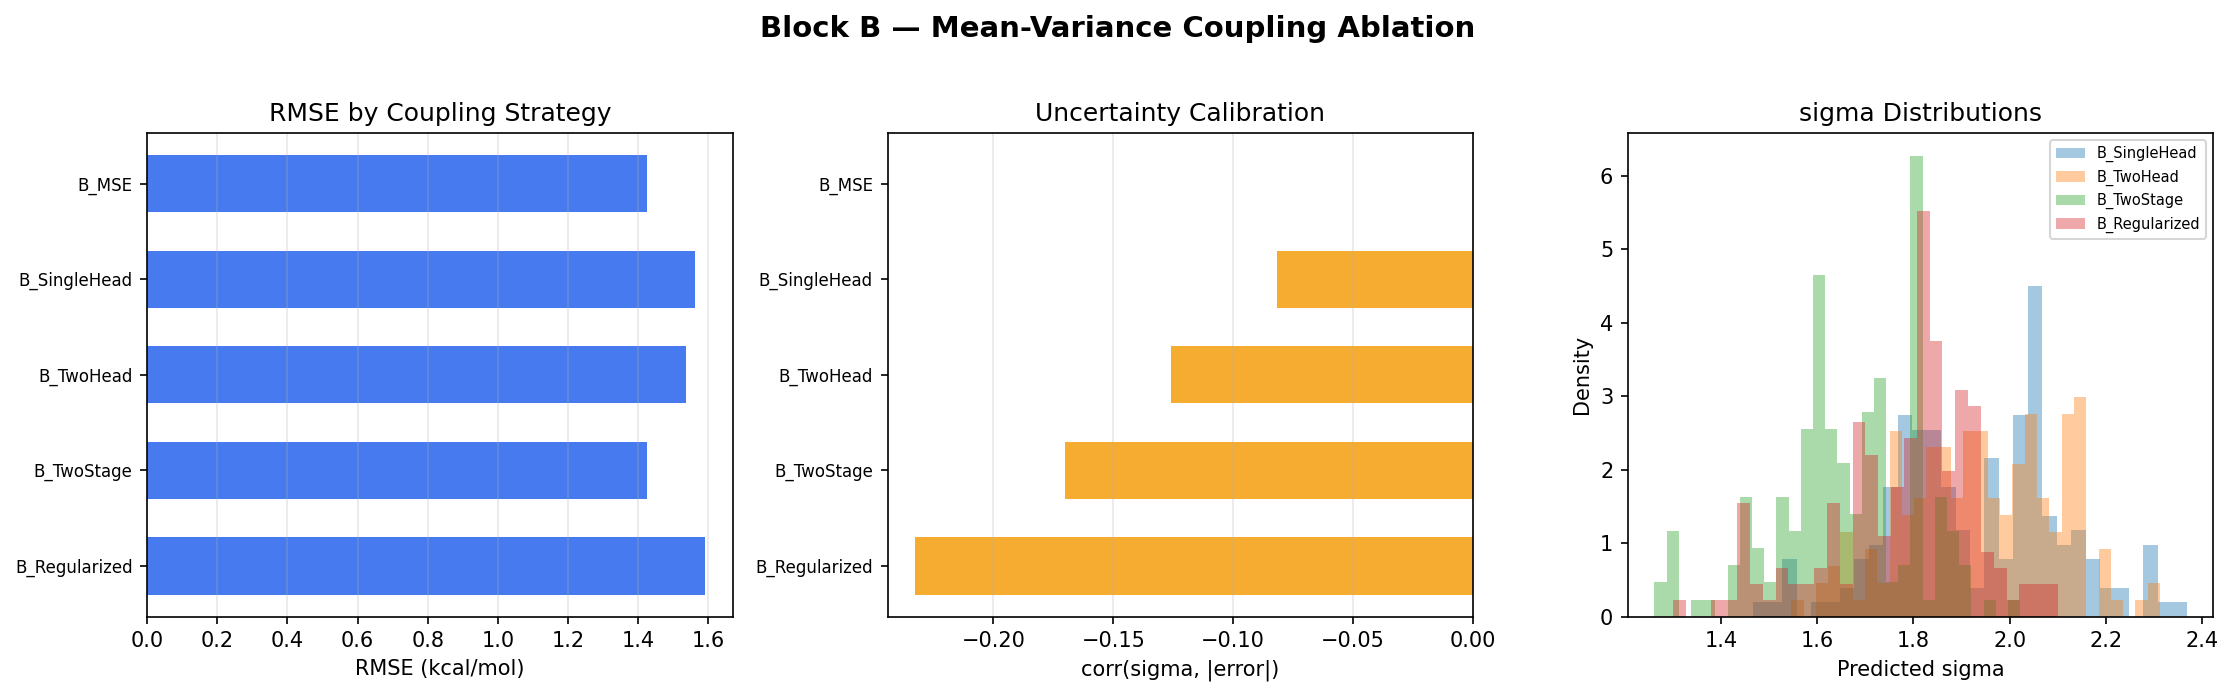

In [8]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
labels_b = df_b["tag"].tolist()
x_b = np.arange(len(labels_b))

# ── RMSE ──
ax = axes[0]
ax.barh(x_b, df_b["RMSE"], color="#2563eb", alpha=0.85, height=0.6)
ax.set_yticks(x_b)
ax.set_yticklabels(labels_b, fontsize=8)
ax.set_xlabel("RMSE (kcal/mol)")
ax.set_title("RMSE by Coupling Strategy")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

# ── corr(sigma, |error|) ──
ax = axes[1]
corr_vals = []
for label in labels_b:
    ex = block_b_extras[label]
    if ex["sigma"] is not None:
        errors = np.abs(ex["y"] - ex["mu"])
        corr_vals.append(np.corrcoef(ex["sigma"], errors)[0, 1])
    else:
        corr_vals.append(0.0)
colors_b = ["#9ca3af" if v == 0 else ("#16a34a" if v > 0.3 else "#f59e0b") for v in corr_vals]
ax.barh(x_b, corr_vals, color=colors_b, alpha=0.85, height=0.6)
ax.set_yticks(x_b)
ax.set_yticklabels(labels_b, fontsize=8)
ax.set_xlabel("corr(sigma, |error|)")
ax.set_title("Uncertainty Calibration")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)

# ── sigma distributions ──
ax = axes[2]
for label in labels_b:
    ex = block_b_extras[label]
    if ex["sigma"] is not None:
        ax.hist(ex["sigma"], bins=30, alpha=0.4, label=label, density=True)
ax.set_xlabel("Predicted sigma")
ax.set_ylabel("Density")
ax.set_title("sigma Distributions")
ax.legend(fontsize=7)

plt.suptitle("Block B — Mean-Variance Coupling Ablation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "block_b_coupling.png")
plt.show()


---
## Block C — Likelihood Family

All experiments use A3 + TwoHeadNLL.

Note: Laplace NLL is not in `uapp.losses`, so we define it here and
monkey-patch `uapp.train._compute_loss` for this block only.


In [9]:

from uapp.train import _compute_loss as _original_compute_loss


def laplace_nll_loss(
    pred_mean: torch.Tensor,
    pred_sigma: torch.Tensor,
    target: torch.Tensor,
    eps: float = 1e-6,
) -> torch.Tensor:
    """Laplace NLL: log(2b) + |y - mu| / b, where b = sigma."""
    b = pred_sigma + eps
    nll = torch.log(2 * b) + torch.abs(target - pred_mean) / b
    return nll.mean()


def _extended_compute_loss(head, X, y, config):
    """Wraps the original _compute_loss with extra loss types for Block C."""
    if config.loss_type == "laplace":
        mu, sigma = head(X)
        if config.sigma_min is not None or config.sigma_max is not None:
            sigma = torch.clamp(
                sigma,
                min=config.sigma_min if config.sigma_min is not None else 0.0,
                max=config.sigma_max if config.sigma_max is not None else 100.0,
            )
        return laplace_nll_loss(mu, sigma, y)
    # For student_t with nu=5, just use the library's student_t with student_t_nu=5
    return _original_compute_loss(head, X, y, config)


# Monkey-patch for Block C
import uapp.train as _train_module
_train_module._compute_loss = _extended_compute_loss


In [10]:

block_c_results: list[EvalResult] = []
block_c_extras: dict[str, dict] = {}

c_experiments = [
    ("C_Gaussian",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="gaussian")),
    ("C_StudentT_v3",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="student_t", student_t_nu=3.0)),
    ("C_StudentT_v5",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="student_t", student_t_nu=5.0)),
    ("C_Laplace",
     TrainConfig(max_epochs=300, lr=1e-3, patience=30, loss_type="laplace")),
]

for label, cfg in c_experiments:
    print(f"\n{'='*55}\n  Block C: {label}\n{'='*55}")
    result, head, extra = run_experiment(
        cache_tag="A3", head_name="two_head_nll",
        train_cfg=cfg, experiment_label=label,
    )
    block_c_results.append(result)
    block_c_extras[label] = extra

# Restore original compute_loss
_train_module._compute_loss = _original_compute_loss

df_c = pd.DataFrame([
    {
        "tag": r.head_name, "RMSE": r.rmse, "MAE": r.mae,
        "NLL": r.nll, "ICE": r.ice,
        "cov@90": r.coverage.get("0.90") if r.coverage else None,
    }
    for r in block_c_results
])
print("\n", df_c.to_string(index=False))


uapp.train | [train] epoch   1 | train 2.6910 | val 1.8155 | best 1.8155 @ ep 1



  Block C: C_Gaussian


uapp.train | [train] epoch  10 | train 0.8091 | val 1.4354 | best 1.1346 @ ep 3
uapp.train | [train] epoch  20 | train 0.5803 | val 1.6947 | best 1.1346 @ ep 3
uapp.train | [train] epoch  30 | train 0.3819 | val 2.1282 | best 1.1346 @ ep 3
uapp.train | [train] early stop at epoch 33 (best 1.1346 @ ep 3)
ablation | [C_Gaussian] n=170
  RMSE : 1.5589
  MAE  : 1.2048
  NLL  : 1.9256
  ICE  : 0.0907
  cov: 0.50→0.688, 0.80→0.929, 0.90→0.953, 0.95→0.971
uapp.train | [train] epoch   1 | train 2.0445 | val 2.0778 | best 2.0778 @ ep 1



  Block C: C_StudentT_v3


uapp.train | [train] epoch  10 | train 1.5483 | val 2.0816 | best 2.0363 @ ep 2
uapp.train | [train] epoch  20 | train 1.3354 | val 2.1779 | best 2.0363 @ ep 2
uapp.train | [train] epoch  30 | train 1.1449 | val 2.2208 | best 2.0363 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 2.0363 @ ep 2)
ablation | [C_StudentT_v3] n=170
  RMSE : 1.4909
  MAE  : 1.0844
  NLL  : 1.8529
  ICE  : 0.0209
  cov: 0.50→0.535, 0.80→0.829, 0.90→0.900, 0.95→0.924
uapp.train | [train] epoch   1 | train 2.2071 | val 2.1136 | best 2.1136 @ ep 1



  Block C: C_StudentT_v5


uapp.train | [train] epoch  10 | train 1.5963 | val 2.1381 | best 2.0253 @ ep 2
uapp.train | [train] epoch  20 | train 1.3484 | val 2.2313 | best 2.0253 @ ep 2
uapp.train | [train] epoch  30 | train 1.1714 | val 2.3066 | best 2.0253 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 2.0253 @ ep 2)
ablation | [C_StudentT_v5] n=170
  RMSE : 1.5463
  MAE  : 1.1689
  NLL  : 1.8780
  ICE  : 0.0522
  cov: 0.50→0.565, 0.80→0.882, 0.90→0.929, 0.95→0.953
uapp.train | [train] epoch   1 | train 2.1192 | val 2.1012 | best 2.1012 @ ep 1



  Block C: C_Laplace


uapp.train | [train] epoch  10 | train 1.5899 | val 2.1339 | best 2.0552 @ ep 2
uapp.train | [train] epoch  20 | train 1.3771 | val 2.1695 | best 2.0552 @ ep 2
uapp.train | [train] epoch  30 | train 1.2048 | val 2.2647 | best 2.0552 @ ep 2
uapp.train | [train] early stop at epoch 32 (best 2.0552 @ ep 2)
ablation | [C_Laplace] n=170
  RMSE : 1.4859
  MAE  : 1.0841
  NLL  : 1.8533
  ICE  : 0.0482
  cov: 0.50→0.588, 0.80→0.882, 0.90→0.924, 0.95→0.947



           tag     RMSE      MAE      NLL      ICE   cov@90
   C_Gaussian 1.558885 1.204812 1.925593 0.090700 0.952941
C_StudentT_v3 1.490882 1.084376 1.852852 0.020947 0.900000
C_StudentT_v5 1.546313 1.168930 1.877999 0.052241 0.929412
    C_Laplace 1.485882 1.084148 1.853260 0.048185 0.923529


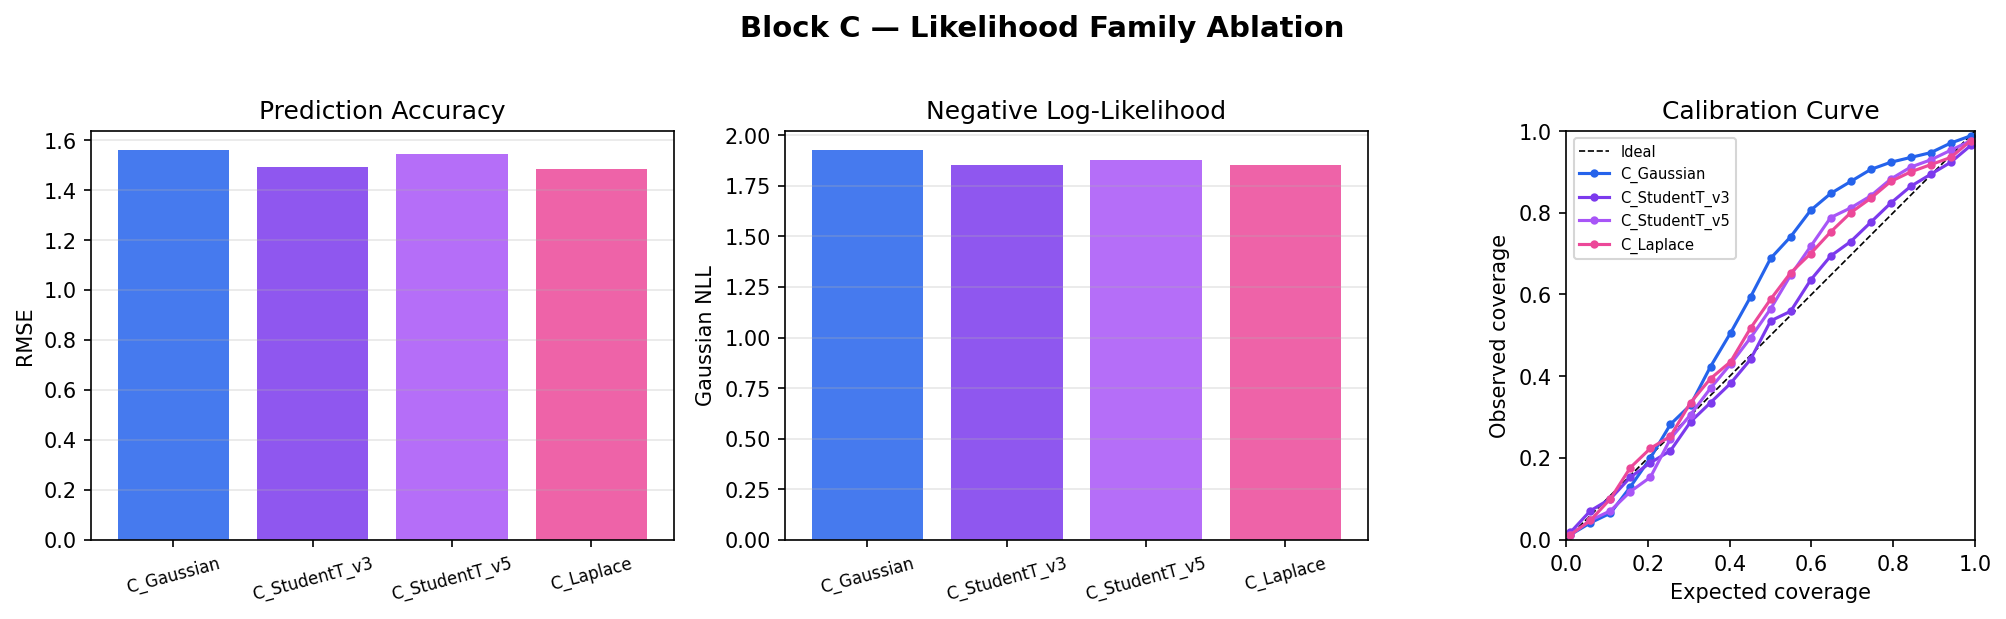

Saved: figures/block_c_reliability.png


In [11]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels_c = df_c["tag"].tolist()
x_c = np.arange(len(labels_c))
palette_c = ["#2563eb", "#7c3aed", "#a855f7", "#ec4899"]

# ── RMSE ──
ax = axes[0]
ax.bar(x_c, df_c["RMSE"], color=palette_c, alpha=0.85)
ax.set_xticks(x_c)
ax.set_xticklabels(labels_c, fontsize=8, rotation=15)
ax.set_ylabel("RMSE")
ax.set_title("Prediction Accuracy")
ax.grid(axis="y", alpha=0.3)

# ── NLL ──
ax = axes[1]
ax.bar(x_c, df_c["NLL"], color=palette_c, alpha=0.85)
ax.set_xticks(x_c)
ax.set_xticklabels(labels_c, fontsize=8, rotation=15)
ax.set_ylabel("Gaussian NLL")
ax.set_title("Negative Log-Likelihood")
ax.grid(axis="y", alpha=0.3)

# ── Calibration curves (using uapp.evaluate.compute_coverage_curve) ──
ax = axes[2]
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="Ideal")
for i, label in enumerate(labels_c):
    ex = block_c_extras[label]
    if ex["sigma"] is not None:
        nominal, empirical = compute_coverage_curve(ex["mu"], ex["sigma"], ex["y"])
        ax.plot(nominal, empirical, "o-", ms=3, lw=1.5, color=palette_c[i], label=label)
ax.set_xlabel("Expected coverage")
ax.set_ylabel("Observed coverage")
ax.set_title("Calibration Curve")
ax.legend(fontsize=7)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal")

plt.suptitle("Block C — Likelihood Family Ablation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "block_c_likelihood.png")
plt.show()

# ── Block C: Reliability diagram via uapp.evaluate ─────────────────
prob_preds_c = {}
for label in labels_c:
    ex = block_c_extras[label]
    if ex["sigma"] is not None:
        prob_preds_c[label] = (ex["mu"], ex["sigma"], ex["y"])

plot_reliability_diagram(
    prob_preds_c,
    out_path=FIG_DIR / "block_c_reliability.png",
    title="Block C — Reliability Diagram",
)
print(f"Saved: {FIG_DIR / 'block_c_reliability.png'}")


---
## Block D — Uncertainty Quality Deep Dive

Uses the best config from Blocks B & C (lowest ICE).


In [12]:

all_prob_results = [r for r in block_b_results + block_c_results if r.ice is not None]
best_result = min(all_prob_results, key=lambda r: r.ice)
best_label = best_result.head_name

all_extras = {**block_b_extras, **block_c_extras}
best_ex = all_extras[best_label]

y_d = best_ex["y"]
mu_d = best_ex["mu"]
sigma_d = best_ex["sigma"]
errors_d = np.abs(y_d - mu_d)

print(f"Best config for Block D: {best_label}")
print(best_result.pretty())


Best config for Block D: C_StudentT_v3
[C_StudentT_v3] n=170
  RMSE : 1.4909
  MAE  : 1.0844
  NLL  : 1.8529
  ICE  : 0.0209
  cov: 0.50→0.535, 0.80→0.829, 0.90→0.900, 0.95→0.924


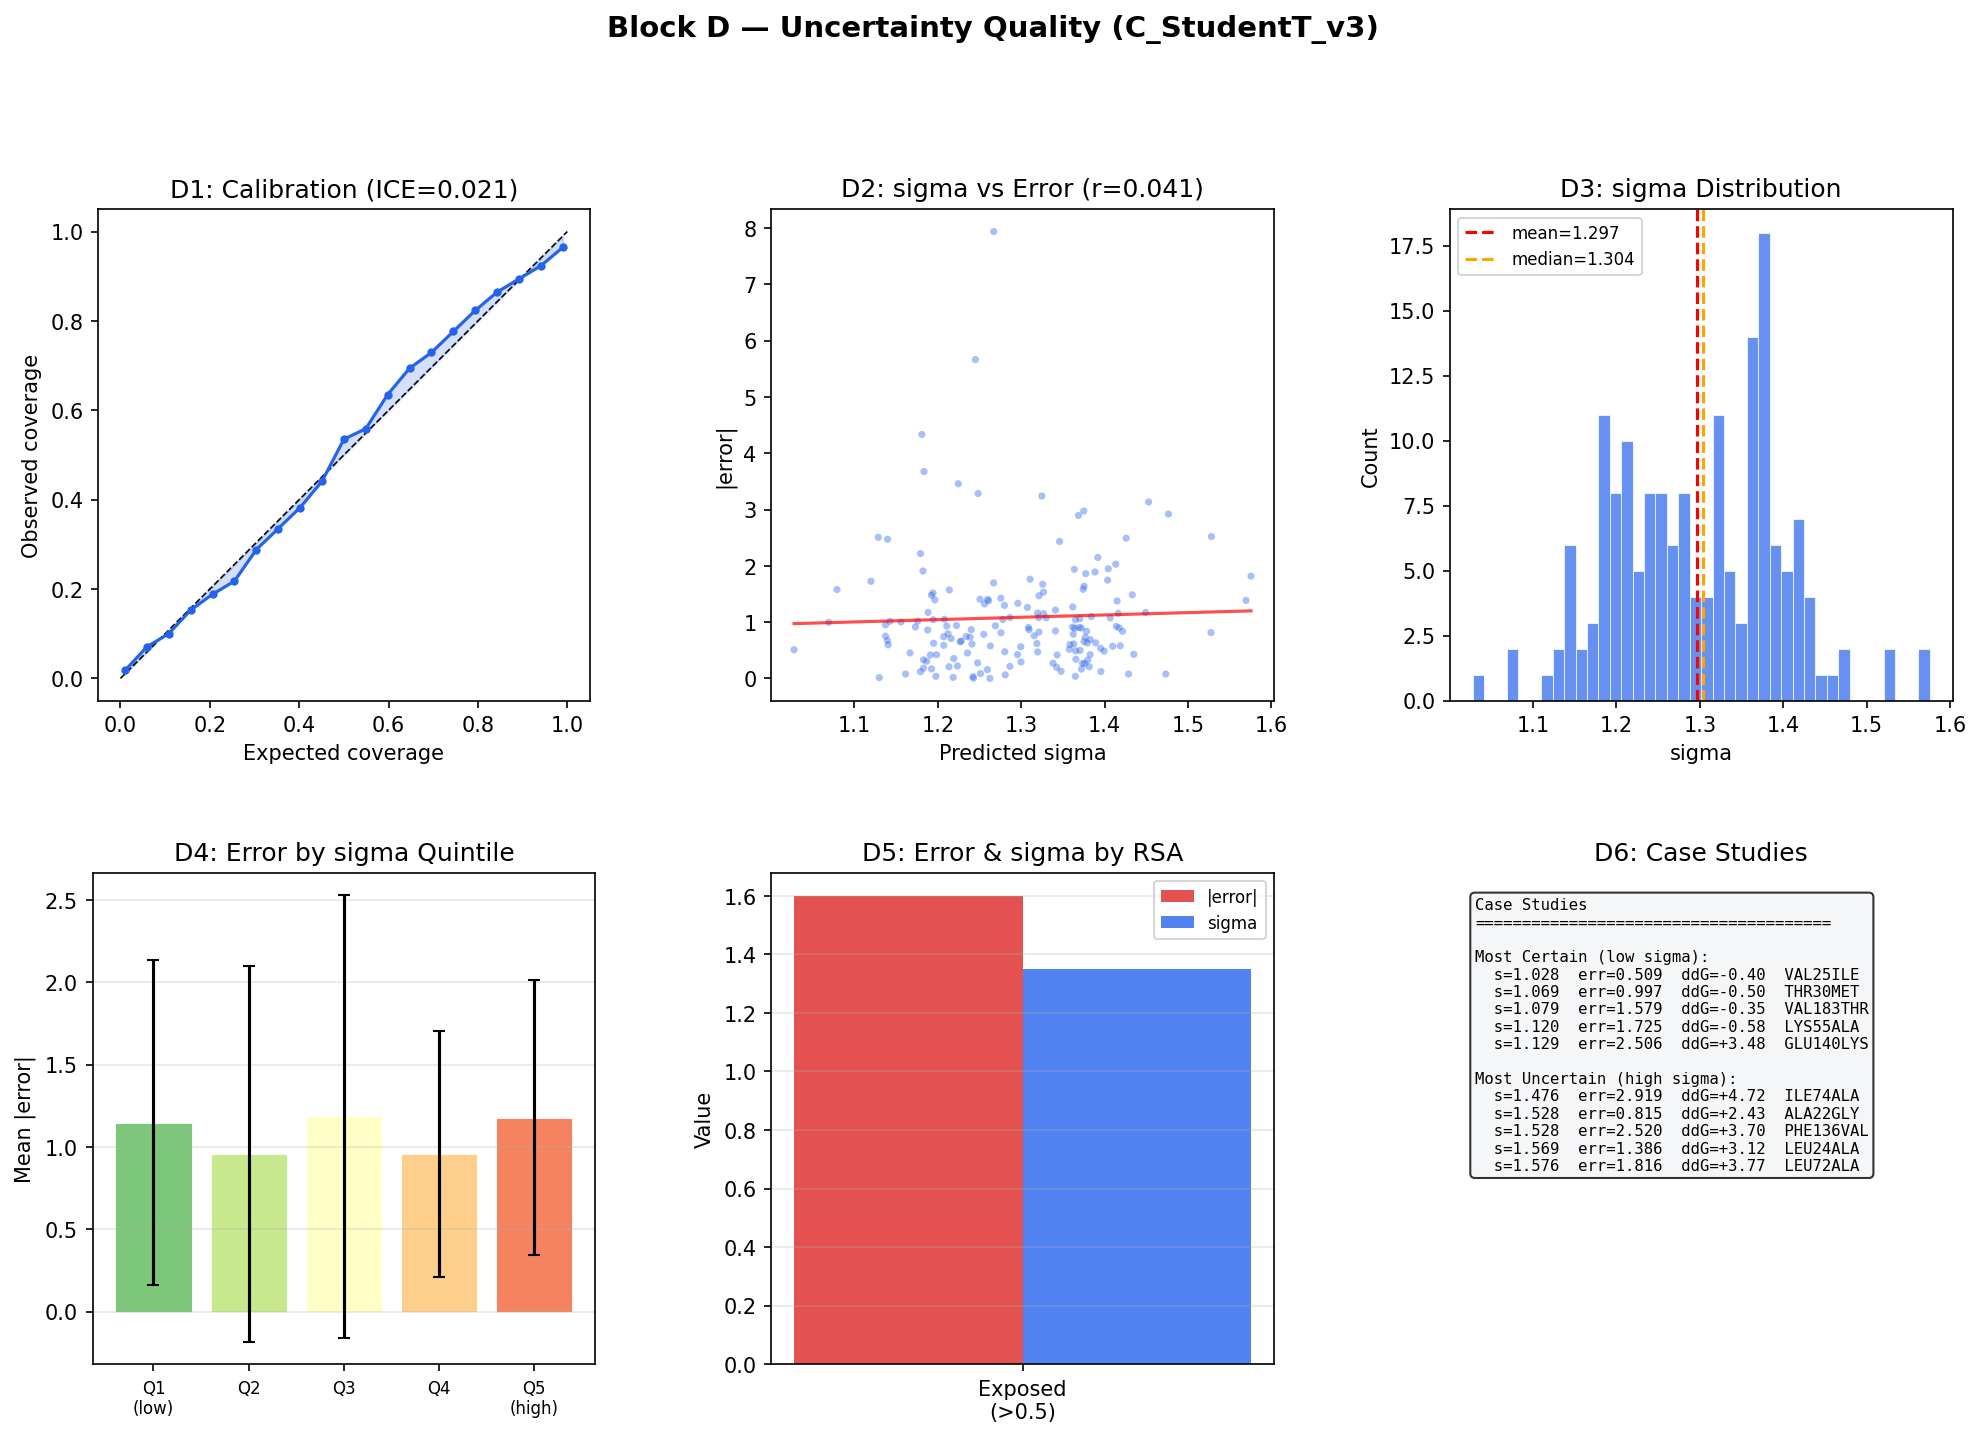

In [13]:

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

# ── D1: Calibration curve (fine-grained) ──
ax = fig.add_subplot(gs[0, 0])
nominal_d, empirical_d = compute_coverage_curve(mu_d, sigma_d, y_d)
ax.fill_between(nominal_d, nominal_d, empirical_d, alpha=0.2, color="#2563eb")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.plot(nominal_d, empirical_d, "o-", color="#2563eb", ms=3, lw=1.5)
ax.set_xlabel("Expected coverage")
ax.set_ylabel("Observed coverage")
ax.set_title(f"D1: Calibration (ICE={best_result.ice:.3f})")
ax.set_aspect("equal")

# ── D2: sigma vs |error| scatter ──
ax = fig.add_subplot(gs[0, 1])
ax.scatter(sigma_d, errors_d, alpha=0.4, s=12, c="#2563eb", edgecolor="none")
r_se = np.corrcoef(sigma_d, errors_d)[0, 1]
z_fit = np.polyfit(sigma_d, errors_d, 1)
xs = np.linspace(sigma_d.min(), sigma_d.max(), 50)
ax.plot(xs, np.polyval(z_fit, xs), "r-", lw=1.5, alpha=0.7)
ax.set_xlabel("Predicted sigma")
ax.set_ylabel("|error|")
ax.set_title(f"D2: sigma vs Error (r={r_se:.3f})")

# ── D3: sigma histogram ──
ax = fig.add_subplot(gs[0, 2])
ax.hist(sigma_d, bins=40, color="#2563eb", alpha=0.7, edgecolor="white", lw=0.5)
ax.axvline(np.mean(sigma_d), color="red", ls="--", label=f"mean={np.mean(sigma_d):.3f}")
ax.axvline(np.median(sigma_d), color="orange", ls="--", label=f"median={np.median(sigma_d):.3f}")
ax.set_xlabel("sigma")
ax.set_ylabel("Count")
ax.set_title("D3: sigma Distribution")
ax.legend(fontsize=8)

# ── D4: Error by sigma quintile ──
ax = fig.add_subplot(gs[1, 0])
sigma_quintiles = pd.qcut(sigma_d, 5, labels=["Q1\n(low)", "Q2", "Q3", "Q4", "Q5\n(high)"])
df_q = pd.DataFrame({"quintile": sigma_quintiles, "error": errors_d})
q_means = df_q.groupby("quintile", observed=True)["error"].mean()
q_stds = df_q.groupby("quintile", observed=True)["error"].std()
colors_q = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 5))
ax.bar(range(5), q_means, yerr=q_stds, color=colors_q, alpha=0.85,
       capsize=3, edgecolor="white", lw=0.5)
ax.set_xticks(range(5))
ax.set_xticklabels(q_means.index, fontsize=8)
ax.set_ylabel("Mean |error|")
ax.set_title("D4: Error by sigma Quintile")
ax.grid(axis="y", alpha=0.3)

# ── D5: RSA stratification ──
ax = fig.add_subplot(gs[1, 1])
test_meta = meta_df[meta_df["split"] == "test"].reset_index(drop=True)
if "rel_rsa" in test_meta.columns and len(test_meta) == len(y_d):
    rsa = test_meta["rel_rsa"].values
    rsa_bins = pd.cut(rsa, bins=[0, 0.2, 0.5, 1.0],
                      labels=["Buried\n(<0.2)", "Inter.\n(0.2-0.5)", "Exposed\n(>0.5)"])
    df_rsa = pd.DataFrame({"rsa_bin": rsa_bins, "error": errors_d, "sigma": sigma_d})
    rsa_err = df_rsa.groupby("rsa_bin", observed=True)["error"].mean()
    rsa_sig = df_rsa.groupby("rsa_bin", observed=True)["sigma"].mean()
    x_rsa = np.arange(len(rsa_err))
    bw = 0.35
    ax.bar(x_rsa - bw / 2, rsa_err, bw, label="|error|", color="#dc2626", alpha=0.8)
    ax.bar(x_rsa + bw / 2, rsa_sig, bw, label="sigma", color="#2563eb", alpha=0.8)
    ax.set_xticks(x_rsa)
    ax.set_xticklabels(rsa_err.index)
    ax.set_ylabel("Value")
    ax.set_title("D5: Error & sigma by RSA")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
else:
    ax.text(0.5, 0.5, "RSA data not aligned\nwith test split",
            ha="center", va="center", transform=ax.transAxes, fontsize=10)
    ax.set_title("D5: RSA Analysis (N/A)")

# ── D6: Case studies ──
ax = fig.add_subplot(gs[1, 2])
ax.axis("off")
sort_idx = np.argsort(sigma_d)
top5_certain = sort_idx[:5]
top5_uncertain = sort_idx[-5:]

lines = ["Case Studies", "=" * 38, "", "Most Certain (low sigma):"]
for i in top5_certain:
    mutation_str = ""
    if len(test_meta) == len(y_d):
        r = test_meta.iloc[i]
        mutation_str = f"  {r.get('wtAA','?')}{r.get('position','?')}{r.get('mutAA','?')}"
    lines.append(f"  s={sigma_d[i]:.3f}  err={errors_d[i]:.3f}  ddG={y_d[i]:+.2f}{mutation_str}")

lines += ["", "Most Uncertain (high sigma):"]
for i in top5_uncertain:
    mutation_str = ""
    if len(test_meta) == len(y_d):
        r = test_meta.iloc[i]
        mutation_str = f"  {r.get('wtAA','?')}{r.get('position','?')}{r.get('mutAA','?')}"
    lines.append(f"  s={sigma_d[i]:.3f}  err={errors_d[i]:.3f}  ddG={y_d[i]:+.2f}{mutation_str}")

ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes, fontsize=7.5,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#f3f4f6", alpha=0.8))
ax.set_title("D6: Case Studies")

plt.suptitle(f"Block D — Uncertainty Quality ({best_label})",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(FIG_DIR / "block_d_uncertainty.png")
plt.show()


In [14]:

all_prob_preds = {}
for label, ex in {**block_b_extras, **block_c_extras}.items():
    if ex["sigma"] is not None:
        all_prob_preds[label] = (ex["mu"], ex["sigma"], ex["y"])

plot_reliability_diagram(
    all_prob_preds,
    out_path=FIG_DIR / "block_d_reliability_all.png",
    title="Reliability Diagram — All Probabilistic Configurations",
)
print(f"Saved: {FIG_DIR / 'block_d_reliability_all.png'}")


Saved: figures/block_d_reliability_all.png


---
## Summary


In [15]:

all_eval_results = block_a_results + block_b_results + block_c_results
save_results_json(all_eval_results, FIG_DIR / "ablation_results.json")

summary_rows = []
for r in all_eval_results:
    row = {
        "experiment": r.head_name,
        "RMSE": round(r.rmse, 4),
        "MAE": round(r.mae, 4),
        "NLL": round(r.nll, 4) if r.nll is not None else None,
        "ICE": round(r.ice, 4) if r.ice is not None else None,
        "cov@50": round(r.coverage["0.50"], 3) if r.coverage and "0.50" in r.coverage else None,
        "cov@80": round(r.coverage["0.80"], 3) if r.coverage and "0.80" in r.coverage else None,
        "cov@90": round(r.coverage["0.90"], 3) if r.coverage and "0.90" in r.coverage else None,
        "cov@95": round(r.coverage["0.95"], 3) if r.coverage and "0.95" in r.coverage else None,
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print("=" * 90)
print("UAPP Ablation Study — Complete Results")
print("=" * 90)
print(df_summary.to_string(index=False))

df_summary.to_csv(FIG_DIR / "ablation_summary.csv", index=False)
print(f"\nSaved: {FIG_DIR / 'ablation_summary.csv'}")
print(f"Saved: {FIG_DIR / 'ablation_results.json'}")


UAPP Ablation Study — Complete Results
   experiment   RMSE    MAE    NLL    ICE  cov@50  cov@80  cov@90  cov@95
         A_A0 1.5689 1.2689 1.8883 0.0261   0.482   0.786   0.867   0.945
         A_A1 1.5071 1.1392 1.8780 0.0622   0.612   0.894   0.935   0.959
         A_A2 1.6123 1.2707 1.9561 0.0797   0.641   0.924   0.959   0.971
         A_A3 1.5558 1.2079 1.9446 0.1039   0.700   0.935   0.965   0.976
         A_A4 1.6113 1.1870 1.9082 0.0765   0.629   0.894   0.935   0.947
        B_MSE 1.4265 0.9939    NaN    NaN     NaN     NaN     NaN     NaN
 B_SingleHead 1.5630 1.1913 1.9274 0.0868   0.676   0.929   0.953   0.959
    B_TwoHead 1.5375 1.1867 1.9182 0.0961   0.700   0.924   0.959   0.976
   B_TwoStage 1.4248 0.9824 1.8359 0.1184   0.671   0.906   0.929   0.947
B_Regularized 1.5903 1.2581 1.9454 0.0595   0.559   0.906   0.941   0.959
   C_Gaussian 1.5589 1.2048 1.9256 0.0907   0.688   0.929   0.953   0.971
C_StudentT_v3 1.4909 1.0844 1.8529 0.0209   0.535   0.829   0.900   0.924

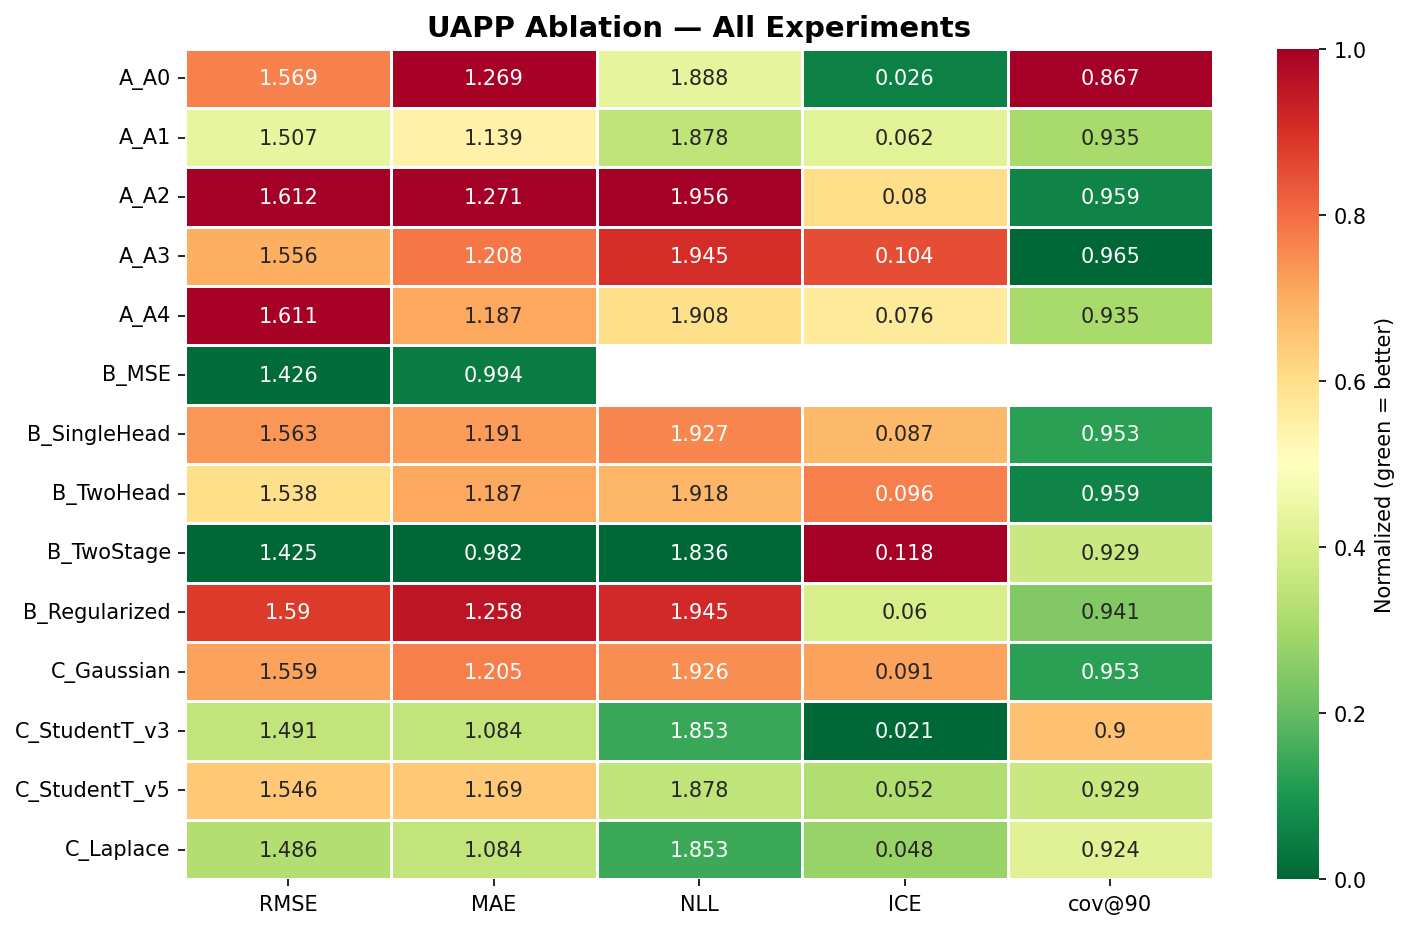


Done! All figures saved to figures/


In [16]:

fig, ax = plt.subplots(figsize=(10, max(6, len(df_summary) * 0.45)))

heat_cols = ["RMSE", "MAE", "NLL", "ICE", "cov@90"]
heat_data = df_summary.set_index("experiment")[[c for c in heat_cols if c in df_summary.columns]].copy()
heat_data = heat_data.apply(pd.to_numeric, errors="coerce")

# Normalize each column to [0,1]
heat_norm = heat_data.copy()
for col in heat_norm.columns:
    rng = heat_norm[col].max() - heat_norm[col].min()
    if rng > 0:
        heat_norm[col] = (heat_norm[col] - heat_norm[col].min()) / rng

# Flip columns where higher = better
for col in ["cov@90"]:
    if col in heat_norm.columns:
        heat_norm[col] = 1 - heat_norm[col]

sns.heatmap(heat_norm, annot=heat_data.round(3).values, fmt="",
            cmap="RdYlGn_r", ax=ax, linewidths=0.5,
            cbar_kws={"label": "Normalized (green = better)"},
            mask=heat_data.isna())
ax.set_title("UAPP Ablation — All Experiments", fontsize=14, fontweight="bold")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(FIG_DIR / "ablation_heatmap.png")
plt.show()

print("\nDone! All figures saved to figures/")
